In [ ]:
# Lab 1-3 –-- The Basics of Python and Pytorch

In [1]:
# problem 1-- sumfunction
def sumnums(list):
    """
    input: list=[]
    output: sum
    """
    sum = 0
    for i in list:
        sum += i
    return sum
# sample
list = [1,2,3,4,5,8]
sumnums(list)    

23

In [2]:
# problem 2 --unique elements 
def unielement(list):
    """ 
    input: list=[]
    output: with unique element of list
    """
    d = {}
    result = []
    for i in list:
        if i not in d:
            d[i] = 1
            result.append(i)
    return result
# small sample
list = [1,2,2,4,5]
unielement(list)

[1, 2, 4, 5]

In [3]:
# problem 3 -- palindorom identity
def palindrome(word):
    """
    input: str
    output: True/Fasle
    """
    word = word.replace(" ", "")
    left = 0 
    right = len(word)-1
    while left != right and left+1 != right :
        if not word[left] == word[right]:
            return False
        left += 1
        right -= 1
    return True
# sample
word = "nurses run"
palindrome(word)


True

In [4]:
# problem 4 -- divide realand imaginary parts
import numpy as np
def get_real_imag_parts(arrays):
    """
    分离实部和虚部
    """
    arrays = np.array(arrays)
    real = arrays.real.tolist()
    imag = arrays.imag.tolist()
    list = []
    list.append(real)
    list.append(imag)
    return list
# sample
a = [ 1.10000000+0.j, 0.70710678+0.70710678j ]
get_real_imag_parts(a)


[[1.1, 0.70710678], [0.0, 0.70710678]]

In [6]:
# problem 5 -- add binary numbers
def addBinary(a, b):
    """
    Input : (’11’, ’1’)
    Output : 100
    """
    i = len(a) - 1
    j = len(b) - 1
    carry = 0
    result = []
    while i >= 0 or j >= 0 or carry:
        total = carry
        if i >= 0:
            total += int(a[i])
            i -= 1
        if j >= 0:
            total += int(b[j])
            j -= 1
        result.append(str(total % 2))
        carry = total // 2
    return ''.join(result[::-1])
# sample test
print(addBinary('11', '1'))

100


In [8]:
# problem 6 -- add two non-empty linked lists
class ListNode:
    def __init__(self, val=0, next=None):
        self.val = val
        self.next = next


def build_linked_list(nums):
    dummy = ListNode(0)
    cur = dummy
    for num in nums:
        cur.next = ListNode(num)
        cur = cur.next
    return dummy.next


def addTwoNumbers(l1, l2):
    """
    Input: (2-> 4-> 3) + (5-> 6-> 4)
    Output: 7-> 0-> 8
    """
    dummy = ListNode(0)
    cur = dummy
    carry = 0
    while l1 or l2 or carry:
        total = carry
        if l1:
            total += l1.val
            l1 = l1.next
        if l2:
            total += l2.val
            l2 = l2.next
        cur.next = ListNode(total % 10)
        carry = total // 10
        cur = cur.next
    return dummy.next
    
def print_linked_list(head):
    cur = head
    while cur:
        print(cur.val, end="")
        if cur.next:
            print(" -> ", end="")
        cur = cur.next
    print()

# simple sample 
l1 = build_linked_list([2, 4, 3])
l2 = build_linked_list([5, 6, 4])
print("l1:")
print_linked_list(l1)
print("l2:")
print_linked_list(l2)
result = addTwoNumbers(l1, l2)
print("result:")
print_linked_list(result)

l1:
2 -> 4 -> 3
l2:
5 -> 6 -> 4
result:
7 -> 0 -> 8


In [9]:
# problem 7 -- bubblesort
def bubble_sort(arr):
    n = len(arr)
    for i in range(n):
        for j in range(0, n - 1 - i):
            if arr[j] > arr[j + 1]:
                arr[j], arr[j + 1] = arr[j + 1], arr[j]
    return arr

nums = [5, 3, 8, 2]
print(bubble_sort(nums))

[2, 3, 5, 8]


In [10]:
#problem 8 --mergesort
def mergesort(arr):
    if len(arr) <= 1:
        return arr

    mid = len(arr) // 2
    left = mergesort(arr[:mid])
    right = mergesort(arr[mid:])

    return merge(left, right)

def merge(left, right):
    result = []
    i = 0
    j = 0

    while i < len(left) and j < len(right):
        if left[i] <= right[j]:
            result.append(left[i])
            i += 1
        else:
            result.append(right[j])
            j += 1

    result.extend(left[i:])
    result.extend(right[j:])
    return result
nums = [5, 3, 8, 2, 1]
print(mergesort(nums))

[1, 2, 3, 5, 8]


In [11]:
#problem 9 -- quicksort
def quicksort(arr):
    if len(arr) <= 1:
        return arr
    pivot = arr[0]
    left = []
    right = []
    equal = []
    for x in arr:
        if x < pivot:
            left.append(x)
        elif x > pivot:
            right.append(x)
        else:
            equal.append(x)

    return quicksort(left) + equal + quicksort(right)
nums = [5, 3, 8, 2, 1]
print(quicksort(nums))

[1, 2, 3, 5, 8]


In [12]:
# problem 10 --shellsort
def shellsort(arr):
    n = len(arr)
    gap = n // 2
    while gap > 0:
        for i in range(gap, n):
            temp = arr[i]
            j = i
            while j >= gap and arr[j - gap] > temp:
                arr[j] = arr[j - gap]
                j -= gap
            arr[j] = temp
        gap //= 2
    return arr
nums = [5, 3, 8, 2, 1]
print(shellsort(nums))

[1, 2, 3, 5, 8]


In [1]:
%pip install torch torchvision torchaudio

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [18]:
# problem 11 -- linearregressionmodel
'''
实现一个简单的线性回归，并对回归的时间进行计时
'''
import torch
import time 
torch.manual_seed(42)
X = torch.randn(2000, 3)
true_w = torch.tensor([[200.0], [-1.5], [3.0]])
true_b = torch.tensor([0.8])
y = X @ true_w + true_b + 0.1 * torch.randn(2000, 1)
W = torch.randn(3, 1, requires_grad=True)
b = torch.randn(1, requires_grad=True)
lr = 0.05
start_time = time.time()
for epoch in range(200):
    y_pred = X @ W + b
    loss = ((y_pred - y) ** 2).mean()
    loss.backward()
    with torch.no_grad():
        W -= lr * W.grad
        b -= lr * b.grad
    W.grad.zero_()
    b.grad.zero_()
    if (epoch + 1) % 20 == 0:
        print(f"Epoch [{epoch+1}/200], Loss: {loss.item():.6f}")
end_time = time.time()
print("learned weight:", W.data.T)
print("learned bias:", b.data)
print(f"训练总耗时: {end_time - start_time:.6f} 秒")  # 输出时间
print("learned weight:", W.data.T)
print("learned bias:", b.data)

Epoch [20/200], Loss: 594.199036
Epoch [40/200], Loss: 6.608265
Epoch [60/200], Loss: 0.084211
Epoch [80/200], Loss: 0.010552
Epoch [100/200], Loss: 0.009700
Epoch [120/200], Loss: 0.009690
Epoch [140/200], Loss: 0.009690
Epoch [160/200], Loss: 0.009690
Epoch [180/200], Loss: 0.009690
Epoch [200/200], Loss: 0.009690
learned weight: tensor([[199.9994,  -1.4962,   3.0012]])
learned bias: tensor([0.7998])
训练总耗时: 11.005636 秒
learned weight: tensor([[199.9994,  -1.4962,   3.0012]])
learned bias: tensor([0.7998])


In [25]:
#problem 12-- logisticregression
'''
完成一个简单的逻辑回归，loss使用熵来计算
'''
import torch
torch.manual_seed(42)
X = torch.randn(3000, 2)
true_w = torch.tensor([[1200.0], [-180.0]])
true_b = torch.tensor([-0.3])
logits = X @ true_w + true_b
probs = torch.sigmoid(logits)
y = (probs > 0.5).float()
W = torch.randn(2, 1, requires_grad=True)
b = torch.randn(1, requires_grad=True)
lr = 0.1
eps = 1e-8
for epoch in range(2000):
    logits_pred = X @ W + b
    probs_pred = torch.sigmoid(logits_pred)
    loss = -(y * torch.log(probs_pred + eps) + (1 - y) * torch.log(1 - probs_pred + eps)).mean()
    loss.backward()
    with torch.no_grad():
        W -= lr * W.grad
        b -= lr * b.grad
    W.grad.zero_()
    b.grad.zero_()

    if (epoch + 1) % 200 == 0:
        with torch.no_grad():
            pred = (probs_pred > 0.5).float()
            acc = (pred == y).float().mean()
        print(f"Epoch [{epoch+1}/2000], Loss: {loss.item():.6f}, Acc: {acc.item():.4f}")

print("learned weight:", W.data.T)
print("learned bias:", b.data)

Epoch [200/2000], Loss: 0.209474, Acc: 0.9840
Epoch [400/2000], Loss: 0.161096, Acc: 0.9943
Epoch [600/2000], Loss: 0.138903, Acc: 0.9960
Epoch [800/2000], Loss: 0.125288, Acc: 0.9963
Epoch [1000/2000], Loss: 0.115790, Acc: 0.9963
Epoch [1200/2000], Loss: 0.108649, Acc: 0.9963
Epoch [1400/2000], Loss: 0.103011, Acc: 0.9960
Epoch [1600/2000], Loss: 0.098401, Acc: 0.9963
Epoch [1800/2000], Loss: 0.094534, Acc: 0.9963
Epoch [2000/2000], Loss: 0.091224, Acc: 0.9963
learned weight: tensor([[ 6.7881, -1.0080]])
learned bias: tensor([0.0496])


In [27]:
# problem 13--linearSVMmodel
'''
完成一个简单的svm模型
'''
import torch
torch.manual_seed(42)
X = torch.randn(1000, 2)
true_w = torch.tensor([[200.0], [-100.5]])
true_b = torch.tensor([0.356])
y = torch.sign(X @ true_w + true_b).view(-1)
y[y == 0] = 1
w = torch.randn(2, 1, requires_grad=True)
b = torch.randn(1, requires_grad=True)
lr = 0.05

for epoch in range(1000):
    scores = X @ w + b
    margins = 1 - y.view(-1, 1) * scores
    loss = torch.clamp(margins, min=0).mean()
    loss.backward()
    with torch.no_grad():
        w -= lr * w.grad
        b -= lr * b.grad
    w.grad.zero_()
    b.grad.zero_()
    if (epoch + 1) % 100 == 0:
        with torch.no_grad():
            pred = torch.where(scores >= 0, torch.ones_like(scores), -torch.ones_like(scores)).view(-1)
            acc = (pred == y).float().mean()
        print(f"Epoch [{epoch+1}/200], Loss: {loss.item():.6f}, Acc: {acc.item():.4f}")

print("learned w:", w.detach().view(-1))
print("learned b:", b.detach())

Epoch [100/200], Loss: 0.266972, Acc: 0.9320
Epoch [200/200], Loss: 0.189841, Acc: 0.9840
Epoch [300/200], Loss: 0.166143, Acc: 0.9840
Epoch [400/200], Loss: 0.151339, Acc: 0.9870
Epoch [500/200], Loss: 0.140517, Acc: 0.9850
Epoch [600/200], Loss: 0.131777, Acc: 0.9840
Epoch [700/200], Loss: 0.125049, Acc: 0.9840
Epoch [800/200], Loss: 0.119619, Acc: 0.9820
Epoch [900/200], Loss: 0.114827, Acc: 0.9820
Epoch [1000/200], Loss: 0.110349, Acc: 0.9820
learned w: tensor([ 3.4931, -1.7413])
learned b: tensor([-0.1025])


In [28]:
# problem 14.1 --Frobenius norm penalty
'''
使用torch函数完成Frobenius函数
'''
import torch
torch.manual_seed(42)
X = torch.randn(1000, 2)
true_w = torch.tensor([[200.0], [-100.5]])
true_b = torch.tensor([0.356])
y = torch.sign(X @ true_w + true_b).view(-1, 1)
y[y == 0] = 1
w = torch.randn(2, 1, requires_grad=True)
b = torch.randn(1, requires_grad=True)
lr = 0.05
lam = 0.01

for epoch in range(1000):
    scores = X @ w + b
    hinge_loss = torch.clamp(1 - y * scores, min=0).mean()
    reg = torch.norm(w, p=2)
    loss = hinge_loss + lam * reg
    loss.backward()
    with torch.no_grad():
        w -= lr * w.grad
        b -= lr * b.grad
    w.grad.zero_()
    b.grad.zero_()

    if (epoch + 1) % 100 == 0:
        with torch.no_grad():
            pred = torch.where(scores >= 0, torch.ones_like(scores), -torch.ones_like(scores))
            acc = (pred == y).float().mean()
        print(f"Epoch [{epoch+1}/200], Loss: {loss.item():.6f}, Acc: {acc.item():.4f}")

print("learned w:", w.detach().view(-1))
print("learned b:", b.detach())

Epoch [100/200], Loss: 0.285313, Acc: 0.9350
Epoch [200/200], Loss: 0.215938, Acc: 0.9830
Epoch [300/200], Loss: 0.196210, Acc: 0.9830
Epoch [400/200], Loss: 0.184477, Acc: 0.9870
Epoch [500/200], Loss: 0.176311, Acc: 0.9860
Epoch [600/200], Loss: 0.170111, Acc: 0.9840
Epoch [700/200], Loss: 0.164990, Acc: 0.9840
Epoch [800/200], Loss: 0.161170, Acc: 0.9840
Epoch [900/200], Loss: 0.158095, Acc: 0.9820
Epoch [1000/200], Loss: 0.155577, Acc: 0.9820
learned w: tensor([ 3.2171, -1.6165])
learned b: tensor([-0.0879])


In [29]:
#problem 14.2 -- Frobenius norm penalty
import torch
torch.manual_seed(42)
X = torch.randn(200, 2)
true_w = torch.tensor([[2.0], [-1.5]])
true_b = torch.tensor([0.3])
y = torch.sign(X @ true_w + true_b).view(-1, 1)
y[y == 0] = 1
w = torch.randn(2, 1, requires_grad=True)
b = torch.randn(1, requires_grad=True)
lr = 0.05
lam = 0.01

for epoch in range(200):
    scores = X @ w + b
    hinge_loss = torch.clamp(1 - y * scores, min=0).mean()
    reg = torch.sqrt(torch.sum(w * w))# 使用公式手动计算
    loss = hinge_loss + lam * reg
    loss.backward()
    with torch.no_grad():
        w -= lr * w.grad
        b -= lr * b.grad
    w.grad.zero_()
    b.grad.zero_()
    if (epoch + 1) % 20 == 0:
        with torch.no_grad():
            pred = torch.where(scores >= 0, torch.ones_like(scores), -torch.ones_like(scores))
            acc = (pred == y).float().mean()
        print(f"Epoch [{epoch+1}/200], Loss: {loss.item():.6f}, Acc: {acc.item():.4f}")

print("learned w:", w.detach().view(-1))
print("learned b:", b.detach())

Epoch [20/200], Loss: 0.363764, Acc: 0.8950
Epoch [40/200], Loss: 0.286419, Acc: 0.9650
Epoch [60/200], Loss: 0.253842, Acc: 1.0000
Epoch [80/200], Loss: 0.232728, Acc: 0.9850
Epoch [100/200], Loss: 0.218723, Acc: 0.9800
Epoch [120/200], Loss: 0.210034, Acc: 0.9600
Epoch [140/200], Loss: 0.203804, Acc: 0.9600
Epoch [160/200], Loss: 0.198639, Acc: 0.9600
Epoch [180/200], Loss: 0.194167, Acc: 0.9600
Epoch [200/200], Loss: 0.189929, Acc: 0.9600
learned w: tensor([ 1.7547, -1.3013])
learned b: tensor([0.0562])


In [30]:
#problem 15--scikitlearn
import numpy as np
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.svm import SVC
from sklearn.metrics import mean_squared_error, accuracy_score
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

# linear regression
rng = np.random.RandomState(42)
X_reg = rng.randn(200, 3)
y_reg = 2 * X_reg[:, 0] - 1.5 * X_reg[:, 1] + 3 * X_reg[:, 2] + 0.8 + 0.1 * rng.randn(200)
Xr_train, Xr_test, yr_train, yr_test = train_test_split(
    X_reg, y_reg, test_size=0.2, random_state=42
)
lin_model = LinearRegression()
lin_model.fit(Xr_train, yr_train)
yr_train_pred = lin_model.predict(Xr_train)
yr_test_pred = lin_model.predict(Xr_test)
print("Linear Regression")
print("coef:", lin_model.coef_)
print("intercept:", lin_model.intercept_)
print("train mse:", mean_squared_error(yr_train, yr_train_pred))
print("test mse:", mean_squared_error(yr_test, yr_test_pred))

# logistic regression
X_clf = rng.randn(10000, 2)
y_clf = (2.5 * X_clf[:, 0] - 1.8 * X_clf[:, 1] - 0.3 > 0).astype(int)
Xc_train, Xc_test, yc_train, yc_test = train_test_split(
    X_clf, y_clf, test_size=0.2, random_state=42, stratify=y_clf
)
log_model = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", LogisticRegression(max_iter=1000, random_state=42))
])
log_model.fit(Xc_train, yc_train)
yc_train_pred_log = log_model.predict(Xc_train)
yc_test_pred_log = log_model.predict(Xc_test)
print("\nLogistic Regression")
print("coef:", log_model.named_steps["clf"].coef_)
print("intercept:", log_model.named_steps["clf"].intercept_)
print("train acc:", accuracy_score(yc_train, yc_train_pred_log))
print("test acc:", accuracy_score(yc_test, yc_test_pred_log))


# SVM model
svm_model = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", SVC(kernel="linear"))
])
svm_model.fit(Xc_train, yc_train)

yc_train_pred_svm = svm_model.predict(Xc_train)
yc_test_pred_svm = svm_model.predict(Xc_test)

print("\nLinear SVM")
print("coef:", svm_model.named_steps["clf"].coef_)
print("intercept:", svm_model.named_steps["clf"].intercept_)
print("train acc:", accuracy_score(yc_train, yc_train_pred_svm))
print("test acc:", accuracy_score(yc_test, yc_test_pred_svm))

Linear Regression
coef: [ 1.99345437 -1.48732457  3.01171611]
intercept: 0.8048990370541338
train mse: 0.01054514539077318
test mse: 0.008594941373179668

Logistic Regression
coef: [[ 14.23582957 -10.03323877]]
intercept: [-1.77933522]
train acc: 0.999125
test acc: 0.9995

Linear SVM
coef: [[11.97946093 -8.43748599]]
intercept: [-1.51900604]
train acc: 0.99925
test acc: 0.9985


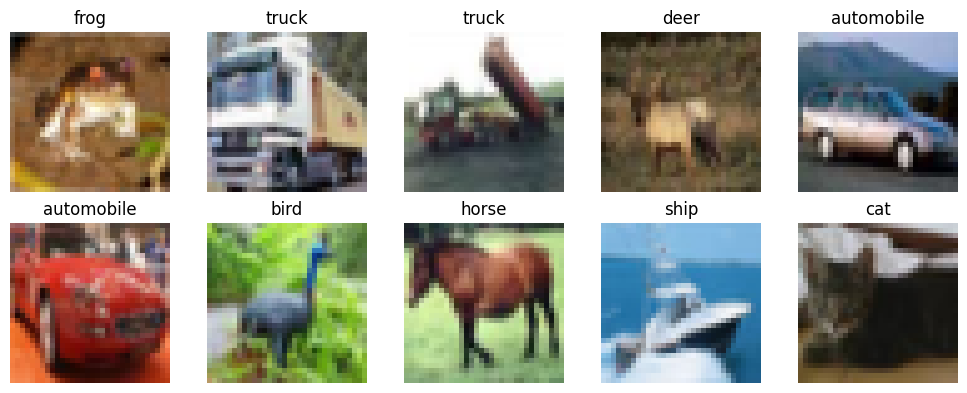

In [32]:
# problem 16--cifar10
%matplotlib inline
import matplotlib.pyplot as plt
from torchvision import datasets, transforms

transform = transforms.ToTensor()
cifar10 = datasets.CIFAR10(
    root="./data",
    train=True,
    download=True,
    transform=transform
)
classes = cifar10.classes
plt.figure(figsize=(10, 4))
for i in range(10):
    img, label = cifar10[i]
    plt.subplot(2, 5, i + 1)
    plt.imshow(img.permute(1, 2, 0))
    plt.title(classes[label])
    plt.axis("off")

plt.tight_layout()
plt.show()

In [33]:
# problem 17--datasetclass
import os
import pickle
import numpy as np
from PIL import Image
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms

class MyCIFAR10(Dataset):
    train_list = [
        "data_batch_1",
        "data_batch_2",
        "data_batch_3",
        "data_batch_4",
        "data_batch_5"
    ]
    test_list = ["test_batch"]

    def __init__(self, root="./data", train=True, transform=None, target_transform=None):
        base_dir = os.path.join(root, "cifar-10-batches-py")
        self.root = base_dir if os.path.exists(base_dir) else root
        self.train = train
        self.transform = transform
        self.target_transform = target_transform
        file_list = self.train_list if train else self.test_list
        data = []
        targets = []
        for file_name in file_list:
            file_path = os.path.join(self.root, file_name)
            with open(file_path, "rb") as f:
                entry = pickle.load(f, encoding="latin1")
                data.append(entry["data"])
                if "labels" in entry:
                    targets.extend(entry["labels"])
                else:
                    targets.extend(entry["fine_labels"])
        self.data = np.vstack(data).reshape(-1, 3, 32, 32).transpose(0, 2, 3, 1)
        self.targets = targets

    def __getitem__(self, index):
        img = Image.fromarray(self.data[index])
        target = self.targets[index]
        if self.transform is not None:
            img = self.transform(img)
        if self.target_transform is not None:
            target = self.target_transform(target)
        return img, target

    def __len__(self):
        return len(self.data)

transform = transforms.ToTensor()
train_dataset = MyCIFAR10(root="./data", train=True, transform=transform)
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)

images, labels = next(iter(train_loader))
print(images.shape)
print(labels[:10])
print(len(train_dataset))

torch.Size([64, 3, 32, 32])
tensor([0, 3, 6, 8, 7, 7, 3, 4, 8, 1])
50000


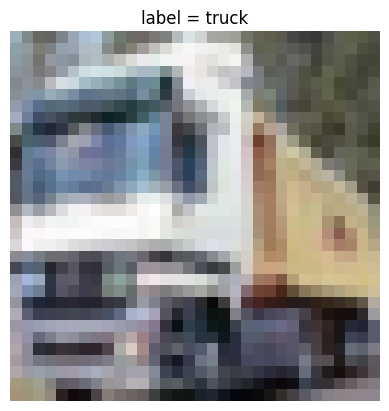

In [34]:
#problem 18-transform
import matplotlib.pyplot as plt
from torchvision import transforms

show_transform = transforms.ToTensor()
show_dataset = MyCIFAR10(root="./data", train=True, transform=show_transform)
img, label = show_dataset[1]
img = img.permute(1, 2, 0).numpy()

plt.imshow(img)
plt.title(f"label = {classes[label]}")
plt.axis("off")
plt.show()

In [6]:
import torch
print(torch.__version__)
print(torch.cuda.is_available())
print(torch.cuda.device_count())
print(torch.version.cuda)

2.11.0+cu126
True
1
12.6


In [ ]:
# problem 19--Dataloader
import time
import torch
from torch.utils.data import DataLoader, Subset
from torchvision import transforms

def benchmark(dataset, batch_size, num_workers, pin_memory):
    loader = DataLoader(
        dataset,
        batch_size=batch_size,
        shuffle=False,
        num_workers=num_workers,
        pin_memory=pin_memory
    )

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    if device.type == "cuda":
        torch.cuda.synchronize()

    start = time.perf_counter()
    total = 0

    for x, y in loader:
        if device.type == "cuda":
            x = x.to(device, non_blocking=True)
            y = y.to(device, non_blocking=True)
        total += x.size(0)

    if device.type == "cuda":
        torch.cuda.synchronize()

    elapsed = time.perf_counter() - start
    return total, elapsed, total / elapsed

full_dataset = MyCIFAR10(root="./data", train=True, transform=transforms.ToTensor())
dataset = Subset(full_dataset, range(10000))

batch_sizes = [1, 4, 64, 1024]
num_workers_list = [0, 1]
pin_memory_list = [False, True]

for batch_size in batch_sizes:
    for num_workers in num_workers_list:
        for pin_memory in pin_memory_list:
            print(f"running: batch_size={batch_size}, num_workers={num_workers}, pin_memory={pin_memory}")
            try:
                total, elapsed, speed = benchmark(
                    dataset,
                    batch_size=batch_size,
                    num_workers=num_workers,
                    pin_memory=pin_memory
                )
                print(
                    f"batch_size={batch_size:4d}, "
                    f"num_workers={num_workers:2d}, "
                    f"pin_memory={str(pin_memory):5s}, "
                    f"time={elapsed:.4f}s, "
                    f"samples/s={speed:.2f}"
                )
            except Exception as e:
                print(
                    f"batch_size={batch_size:4d}, "
                    f"num_workers={num_workers:2d}, "
                    f"pin_memory={str(pin_memory):5s}, "
                    f"error={e}"
                )

running: batch_size=1, num_workers=0, pin_memory=False
batch_size=   1, num_workers= 0, pin_memory=False, time=5.2156s, samples/s=1917.32
running: batch_size=1, num_workers=0, pin_memory=True
batch_size=   1, num_workers= 0, pin_memory=True , time=6.6112s, samples/s=1512.58
running: batch_size=1, num_workers=1, pin_memory=False


In [38]:
# problem 20 -- mean and std of each RGB channel.
import torch
from torch.utils.data import DataLoader
from torchvision import transforms

dataset = MyCIFAR10(root="./data", train=True, transform=transforms.ToTensor())
loader = DataLoader(dataset, batch_size=512, shuffle=False, num_workers=0)
channel_sum = torch.zeros(3, dtype=torch.float64)
channel_sum_sq = torch.zeros(3, dtype=torch.float64)
num_pixels = 0
for images, _ in loader:
    images = images.to(torch.float64)
    channel_sum += images.sum(dim=(0, 2, 3))
    channel_sum_sq += (images ** 2).sum(dim=(0, 2, 3))
    num_pixels += images.size(0) * images.size(2) * images.size(3)
mean = channel_sum / num_pixels
std = torch.sqrt(channel_sum_sq / num_pixels - mean ** 2)
print("mean:", mean)
print("std :", std)

mean: tensor([0.4914, 0.4822, 0.4465], dtype=torch.float64)
std : tensor([0.2470, 0.2435, 0.2616], dtype=torch.float64)


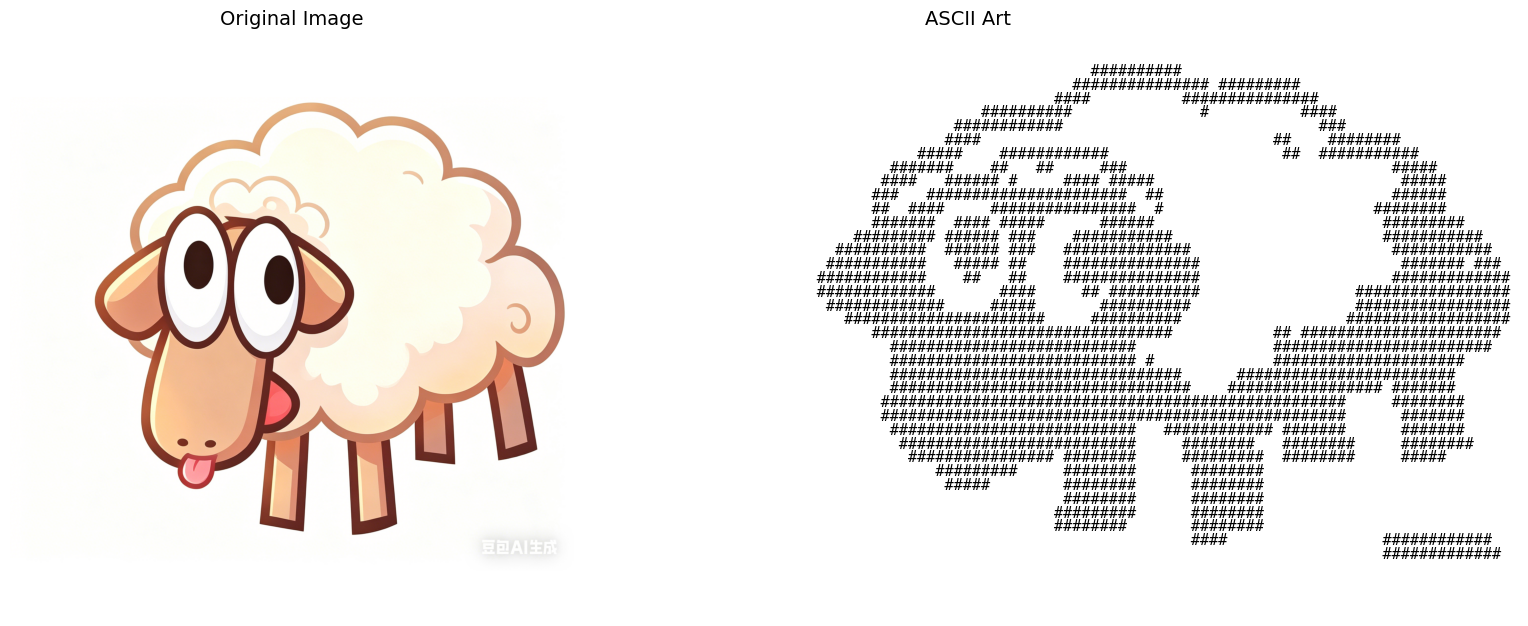

In [37]:
#problem 21 --  character painting
from PIL import Image, ImageOps, ImageFilter
import matplotlib
import matplotlib.pyplot as plt

matplotlib.rcParams["text.parse_math"] = False
def image_to_ascii(image_path, output_txt="ascii_art.txt", width=60, chars="@#S%?*+;:,. "):
    original_img = Image.open(image_path).convert("RGB")
    gray = ImageOps.grayscale(original_img)
    gray = ImageOps.autocontrast(gray)
    gray = gray.filter(ImageFilter.EDGE_ENHANCE_MORE)
    w, h = gray.size
    height = max(1, int(h * width / w * 0.5))
    gray = gray.resize((width, height))
    pixels = gray.load()
    lines = []
    for y in range(height):
        line = []
        for x in range(width):
            g = pixels[x, y]
            if g > 245:
                ch = " "
            else:
                idx = g * (len(chars) - 1) // 255
                ch = chars[idx]
            line.append(ch)
        lines.append("".join(line))
    ascii_str = "\n".join(lines)
    with open(output_txt, "w", encoding="utf-8") as f:
        f.write(ascii_str)
    return original_img, ascii_str

def show_original_and_ascii(original_img, ascii_str):
    fig, axes = plt.subplots(1, 2, figsize=(16, 8), gridspec_kw={"width_ratios": [1, 1]})

    axes[0].imshow(original_img)
    axes[0].set_title("Original Image", fontsize=14, pad=20)
    axes[0].axis("off")
    axes[1].text(
        0.02,
        0.98,
        ascii_str,
        transform=axes[1].transAxes,
        family="monospace",
        fontsize=11,
        va="top",
        ha="left",
        linespacing=0.9,
        parse_math=False
    )
    axes[1].set_title("ASCII Art", fontsize=14, pad=20)
    axes[1].axis("off")
    for ax in axes:
        ax.set_box_aspect(1)
        ax.set_anchor("N")
    plt.subplots_adjust(top=0.85, wspace=0.2)
    plt.show()
image_path = "input.png"
original_img, ascii_art = image_to_ascii(
    image_path=image_path,
    output_txt="ascii_art.txt",
    width=90,
    chars="#"
)

show_original_and_ascii(original_img, ascii_art)

In [4]:
#problem 22.1
import numpy as np
np.random.seed(42)
def cartesian_to_polar(Z):
    polar = np.zeros_like(Z)
    for i in range(Z.shape[0]):
        x = Z[i, 0]
        y = Z[i, 1]
        r = (x ** 2 + y ** 2) ** 0.5
        theta = np.arctan2(y, x)
        polar[i, 0] = r
        polar[i, 1] = theta
    return polar

Z = np.random.rand(10, 2)
polar = cartesian_to_polar(Z)
print("Cartesian:")
print(Z)
print("\nPolar:")
print(polar)

Cartesian:
[[0.37454012 0.95071431]
 [0.73199394 0.59865848]
 [0.15601864 0.15599452]
 [0.05808361 0.86617615]
 [0.60111501 0.70807258]
 [0.02058449 0.96990985]
 [0.83244264 0.21233911]
 [0.18182497 0.18340451]
 [0.30424224 0.52475643]
 [0.43194502 0.29122914]]

Polar:
[[1.02183071 1.19551066]
 [0.94562525 0.68552846]
 [0.22062662 0.78532086]
 [0.86812143 1.50383906]
 [0.9288197  0.86691479]
 [0.97012826 1.54957641]
 [0.85909758 0.24975369]
 [0.25825866 0.78972293]
 [0.60657453 1.04537865]
 [0.52095193 0.59321867]]


In [5]:
#problem 22.2
import numpy as np

class SymmetricArray(np.ndarray):
    def __new__(cls, input_array):
        arr = np.asarray(input_array, dtype=float)
        if arr.ndim != 2 or arr.shape[0] != arr.shape[1]:
            raise ValueError("input must be a square 2D array")
        arr = (arr + arr.T) / 2
        return arr.view(cls)

    def __setitem__(self, key, value):
        super().__setitem__(key, value)
        if isinstance(key, tuple) and len(key) == 2:
            i, j = key
            super().__setitem__((j, i), value)

Z = SymmetricArray([[1, 2, 3],
                    [4, 5, 6],
                    [7, 8, 9]])

print(Z)

Z[0, 2] = 100
print("\nAfter setting Z[0,2] = 100:")
print(Z)

[[1. 3. 5.]
 [3. 5. 7.]
 [5. 7. 9.]]

After setting Z[0,2] = 100:
[[  1.   3. 100.]
 [  3.   5.   7.]
 [100.   7.   9.]]


In [8]:
#problem 22.3
'''
行：直线
列：点
元素值：该点到该直线的距离
'''
import numpy as np

def point_to_line_distances(P0, P1, P):
    A = P0[:, None, :]
    B = P1[:, None, :]
    X = P[None, :, :]

    AB = B - A
    AX = X - A

    cross = AB[:, :, 0] * AX[:, :, 1] - AB[:, :, 1] * AX[:, :, 0]
    length = np.sqrt(np.sum(AB ** 2, axis=2))

    dist = np.abs(cross) / length
    return dist

P0 = np.array([[0, 0],
               [1, 1],
               [2, 0]], dtype=float)

P1 = np.array([[1, 0],
               [2, 2],
               [2, 2]], dtype=float)

P = np.array([[1, 1],
              [3, 1],
              [0, 2]], dtype=float)

dist = point_to_line_distances(P0, P1, P)

print("distance matrix shape:", dist.shape)
print(dist)

distance matrix shape: (3, 3)
[[1.         1.         2.        ]
 [0.         1.41421356 1.41421356]
 [1.         1.         2.        ]]


In [9]:
# problem23 --Bilinear Interpolation
import numpy as np

def bilinear_interpolation(A, point):
    A = np.asarray(A, dtype=float)
    if A.ndim != 2:
        raise ValueError("A must be a 2D array")

    r, c = point
    rows, cols = A.shape

    if not (1 <= r <= rows and 1 <= c <= cols):
        raise ValueError("point is out of range")

    r1 = int(np.floor(r))
    r2 = int(np.ceil(r))
    c1 = int(np.floor(c))
    c2 = int(np.ceil(c))

    if r1 == r2 and c1 == c2:
        return A[r1 - 1, c1 - 1]

    if r1 == r2:
        q1 = A[r1 - 1, c1 - 1]
        q2 = A[r1 - 1, c2 - 1]
        return q1 * (c2 - c) + q2 * (c - c1)

    if c1 == c2:
        q1 = A[r1 - 1, c1 - 1]
        q2 = A[r2 - 1, c1 - 1]
        return q1 * (r2 - r) + q2 * (r - r1)

    Q11 = A[r1 - 1, c1 - 1]
    Q12 = A[r1 - 1, c2 - 1]
    Q21 = A[r2 - 1, c1 - 1]
    Q22 = A[r2 - 1, c2 - 1]

    value = (
        Q11 * (r2 - r) * (c2 - c) +
        Q21 * (r - r1) * (c2 - c) +
        Q12 * (r2 - r) * (c - c1) +
        Q22 * (r - r1) * (c - c1)
    ) / ((r2 - r1) * (c2 - c1))

    return value

A = (
    (110, 120, 130),
    (210, 220, 230),
    (310, 320, 330)
)

print(bilinear_interpolation(A, (1, 1)))
print(bilinear_interpolation(A, (2.5, 2.5)))

110.0
275.0


In [11]:
# problem 24 -- Cartesian product
import numpy as np

def cartesian_product(*arrays):
    result = [[]]
    for arr in arrays:
        new_result = []
        for prefix in result:
            for x in arr:
                new_result.append(prefix + [x])
        result = new_result
    return np.array(result)

a = [1, 2, 3]
b = [4, 5]
c = [6, 7]

result = cartesian_product(a, b, c)
print(result)

[[1 4 6]
 [1 4 7]
 [1 5 6]
 [1 5 7]
 [2 4 6]
 [2 4 7]
 [2 5 6]
 [2 5 7]
 [3 4 6]
 [3 4 7]
 [3 5 6]
 [3 5 7]]


In [13]:
#problem 25 -- Extracting a subpart of an array
import numpy as np

def extract_subpart(Z, shape, position, fill=0):
    Z = np.asarray(Z)

    if len(shape) != Z.ndim or len(position) != Z.ndim:
        raise ValueError("shape and position must match the number of dimensions of Z")

    dtype = np.result_type(Z, fill)
    out = np.full(shape, fill, dtype=dtype)
    src_slices = []
    dst_slices = []

    for dim_size, sub_size, pos in zip(Z.shape, shape, position):
        start = pos - sub_size // 2
        end = start + sub_size
        src_start = max(start, 0)
        src_end = min(end, dim_size)
        dst_start = src_start - start
        dst_end = dst_start + (src_end - src_start)
        src_slices.append(slice(src_start, src_end))
        dst_slices.append(slice(dst_start, dst_end))
    out[tuple(dst_slices)] = Z[tuple(src_slices)]
    return out

Z = np.array([[3, 6, 8, 5, 9],
              [4, 9, 0, 0, 9],
              [6, 1, 4, 0, 8],
              [9, 1, 2, 0, 9],
              [4, 1, 7, 5, 0]])

shape = (4, 4)
fill = 0
position = (1, 1)

result = extract_subpart(Z, shape, position, fill)

print("Z:")
print(Z)
print("\nResult:")
print(result)

Z:
[[3 6 8 5 9]
 [4 9 0 0 9]
 [6 1 4 0 8]
 [9 1 2 0 9]
 [4 1 7 5 0]]

Result:
[[0 0 0 0]
 [0 3 6 8]
 [0 4 9 0]
 [0 6 1 4]]


In [15]:
# problem 26--Matrix operations

def check_matrix(matrix):
    if not matrix or not isinstance(matrix, list):
        raise ValueError("matrix must be a non-empty 2D list")
    row_len = len(matrix[0])
    if row_len == 0:
        raise ValueError("matrix must not have empty rows")
    for row in matrix:
        if not isinstance(row, list) or len(row) != row_len:
            raise ValueError("matrix rows must have the same length")

def shape(matrix):
    check_matrix(matrix)
    return len(matrix), len(matrix[0])

def add(A, B):
    ra, ca = shape(A)
    rb, cb = shape(B)
    if ra != rb or ca != cb:
        raise ValueError("matrix sizes do not match")
    return [[A[i][j] + B[i][j] for j in range(ca)] for i in range(ra)]

def subtract(A, B):
    ra, ca = shape(A)
    rb, cb = shape(B)
    if ra != rb or ca != cb:
        raise ValueError("matrix sizes do not match")
    return [[A[i][j] - B[i][j] for j in range(ca)] for i in range(ra)]

def scalar_multiply(A, k):
    ra, ca = shape(A)
    return [[A[i][j] * k for j in range(ca)] for i in range(ra)]

def multiply(A, B):
    ra, ca = shape(A)
    rb, cb = shape(B)
    if ca != rb:
        raise ValueError("invalid matrix dimensions for multiplication")
    result = []
    for i in range(ra):
        row = []
        for j in range(cb):
            s = 0
            for k in range(ca):
                s += A[i][k] * B[k][j]
            row.append(s)
        result.append(row)
    return result

def identity(n):
    if n <= 0:
        raise ValueError("n must be positive")
    return [[1 if i == j else 0 for j in range(n)] for i in range(n)]

def transpose(A):
    r, c = shape(A)
    return [[A[i][j] for i in range(r)] for j in range(c)]

def inverse(A):
    n, m = shape(A)
    if n != m:
        raise ValueError("only square matrices can be inverted")
    aug = []
    I = identity(n)
    for i in range(n):
        aug.append([float(x) for x in A[i]] + [float(x) for x in I[i]])
    for col in range(n):
        pivot_row = col
        while pivot_row < n and aug[pivot_row][col] == 0:
            pivot_row += 1
        if pivot_row == n:
            raise ValueError("matrix is singular and cannot be inverted")
        if pivot_row != col:
            aug[col], aug[pivot_row] = aug[pivot_row], aug[col]
        pivot = aug[col][col]
        for j in range(2 * n):
            aug[col][j] /= pivot
        for i in range(n):
            if i != col:
                factor = aug[i][col]
                for j in range(2 * n):
                    aug[i][j] -= factor * aug[col][j]
    inv = []
    for i in range(n):
        inv.append(aug[i][n:])
    return inv

matrix_a = [[12, 10], [3, 9]]
matrix_b = [[3, 4], [7, 4]]
matrix_c = [[11, 12, 13, 14], [21, 22, 23, 24], [31, 32, 33, 34], [41, 42, 43, 44]]
matrix_d = [[3, 0, 2], [2, 0, -2], [0, 1, 1]]

print("add(matrix_a, matrix_b) =", add(matrix_a, matrix_b))
print("subtract(matrix_a, matrix_b) =", subtract(matrix_a, matrix_b))
print("scalar_multiply(matrix_b, 3) =", scalar_multiply(matrix_b, 3))
print("multiply(matrix_a, matrix_b) =", multiply(matrix_a, matrix_b))
print("identity(3) =", identity(3))
print("transpose(matrix_c) =", transpose(matrix_c))
print("inverse(matrix_d) =", inverse(matrix_d))

add(matrix_a, matrix_b) = [[15, 14], [10, 13]]
subtract(matrix_a, matrix_b) = [[9, 6], [-4, 5]]
scalar_multiply(matrix_b, 3) = [[9, 12], [21, 12]]
multiply(matrix_a, matrix_b) = [[106, 88], [72, 48]]
identity(3) = [[1, 0, 0], [0, 1, 0], [0, 0, 1]]
transpose(matrix_c) = [[11, 21, 31, 41], [12, 22, 32, 42], [13, 23, 33, 43], [14, 24, 34, 44]]
inverse(matrix_d) = [[0.19999999999999998, 0.2, 0.0], [-0.2, 0.30000000000000004, 1.0], [0.2, -0.30000000000000004, -0.0]]


In [17]:
# problem 27--gcd
def gcd(a, b):
    a = abs(a)
    b = abs(b)

    while b != 0:
        a, b = b, a % b

    return a

print("GCD(3, 5) =", gcd(3, 5))
print("GCD(6, 3) =", gcd(6, 3))
print("GCD(-2, 6) =", gcd(-2, 6))
print("GCD(0, 3) =", gcd(0, 3))

GCD(3, 5) = 1
GCD(6, 3) = 3
GCD(-2, 6) = 2
GCD(0, 3) = 3


In [19]:
# problem 28 --tile 

def tile_2xn(n):
    if n < 0:
        raise ValueError("n must be non-negative")
    dp = [0] * (n + 1)
    dp[0] = 1
    if n >= 1:
        dp[1] = 1
    for i in range(2, n + 1):
        dp[i] = dp[i - 1] + 2 * dp[i - 2]
    return dp[n]

for n in range(8):
    print(f"n = {n}, ways = {tile_2xn(n)}")


n = 0, ways = 1
n = 1, ways = 1
n = 2, ways = 3
n = 3, ways = 5
n = 4, ways = 11
n = 5, ways = 21
n = 6, ways = 43
n = 7, ways = 85


In [ ]:
# problem29 --password
def is_valid_password(password):
    if len(password) < 6 or len(password) > 12:
        return False
    has_lower = False
    has_upper = False
    has_digit = False
    has_special = False
    for ch in password:
        if 'a' <= ch <= 'z':
            has_lower = True
        elif 'A' <= ch <= 'Z':
            has_upper = True
        elif '0' <= ch <= '9':
            has_digit = True
        elif ch in "$#@":
            has_special = True
    return has_lower and has_upper and has_digit and has_special

def check_passwords(s):
    passwords = s.split(",")
    valid = []

    for password in passwords:
        if is_valid_password(password):
            valid.append(password)

    return ",".join(valid)

s = "ABd1234@1,a F1#,2w3E*,2We3345"
print(check_passwords(s))